# 01 — Exploratory Data Analysis (EDA)

**Project:** Divar Real Estate Market Analysis  
**Authors:** Kourosh Khodaei Namin, Zeinab Hosseini, Ilia Taherinia  
**Institute:** Daqiqe Data Analysis School  
**Date:** Autumn 1404 (2025–2026)

---

## Overview

This notebook performs the **initial exploration** of the Divar real estate ads dataset
(`divar_real_estate_ads.csv`, ~1 M rows, 60 columns).

### Goals
1. Understand the raw structure: dtypes, shape, sample rows.
2. Identify missing values, duplicates, and obvious data quality issues.
3. Classify columns into thematic groups (numeric continuous, numeric discrete, categorical, binary, text).
4. Visualise distributions to motivate cleaning decisions made in Notebook 02.

### Key Findings
- The dataset contains a mix of Persian/English strings, Persian numerals, symbols, and NaNs.
- Many quantitative columns (price, size, year) have > 50% missing values.
- Extreme outliers exist in price and area columns — handled in the cleaning stage.
- After filtering to **Tehran-only** listings, ~250 k rows remain for downstream analysis.

### Data path
Place `divar_real_estate_ads.csv` in the `../data/` directory before running.
See `../data/README.md` for dataset download instructions.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv(r"C:\Users\kourosh\Desktop\daqiqe Project\1\divar_real_estate_ads.csv")

In [6]:
df.head()

,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,NaN,...,NaN,4.0,6,350000.0,1500000.0,3.500000e+09,3500000.0,35.811684,50.936600,500.0
1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,26000000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN
3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,95000000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01 00:00:00,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 🗂️ توضیحات ویژگی‌های هر ستون

---

#### 🏷️ دسته‌بندی  
- **cat2_slug, cat3_slug:** شناسه‌های دسته‌بندی ملک  
- **property_type:** نوع ملک (آپارتمان، ویلا، زمین و...)  

---

#### 📍 موقعیت مکانی  
- **city_slug, neighborhood_slug:** شناسه‌های شهر و محله  
- **location_latitude, location_longitude:** مختصات جغرافیایی  
- **location_radius:** شعاع دقت موقعیت مکانی  

---

#### 📝 جزئیات آگهی  
- **created_at_month:** زمان ایجاد آگهی  
- **user_type:** نوع کاربر (شخصی، آژانس و...)  
- **description, title:** توضیحات و عنوان ملک  

---

#### 💰 اطلاعات مالی  
- **مربوط به اجاره:** rent_mode، rent_value، rent_to_single، rent_type  
- **مربوط به قیمت:** price_mode، price_value  
- **مربوط به رهن:** credit_mode، credit_value  
- **مقادیر تبدیل‌شده:** شاخص‌های مالی پردازش‌شده برای تحلیل  

---

#### 🏢 مشخصات ملک  
- **land_size, building_size:** متراژ زمین و بنا (متر مربع)  
- **deed_type, has_business_deed:** اطلاعات حقوقی و نوع سند  
- **floor, rooms_count, total_floors_count, unit_per_floor:** ساختار طبقات و تعداد واحدها  
- **construction_year, is_rebuilt:** سال ساخت و وضعیت بازسازی  

---

#### 🛋️ امکانات و ویژگی‌ها  
- **تأسیسات:** has_water، has_electricity، has_gas  
- **کنترل دما:** has_heating_system، has_cooling_system  
- **امکانات رفاهی:** has_balcony، has_elevator، has_warehouse، has_parking  
- **ویژگی‌های لوکس:** has_pool، has_jacuzzi، has_sauna  
- **سایر ویژگی‌ها:** has_security_guard، has_barbecue، building_direction، floor_material  

---

#### 🏨 اطلاعات اجاره کوتاه‌مدت  
- **regular_person_capacity, extra_person_capacity:** ظرفیت افراد معمول و اضافی  
- **cost_per_extra_person:** هزینه‌ی هر نفر اضافه  
- **تفاوت قیمت‌ها:** rent_price_on_regular_days، rent_price_on_special_days، rent_price_at_weekends  


In [56]:
df.dtypes

cat2_slug                      object
cat3_slug                      object
city_slug                      object
neighborhood_slug              object
created_at_month               object
user_type                      object
description                    object
title                          object
rent_mode                      object
rent_value                    float64
rent_to_single                 object
rent_type                      object
price_mode                     object
price_value                   float64
credit_mode                    object
credit_value                  float64
rent_credit_transform          object
transformable_price            object
transformable_credit          float64
transformed_credit            float64
transformable_rent            float64
transformed_rent              float64
land_size                     float64
building_size                 float64
deed_type                      object
has_business_deed              object
floor       

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 60 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   cat2_slug                   1000000 non-null  object 
 1   cat3_slug                   999999 non-null   object 
 2   city_slug                   999998 non-null   object 
 3   neighborhood_slug           437139 non-null   object 
 4   created_at_month            1000000 non-null  object 
 5   user_type                   288882 non-null   object 
 6   description                 1000000 non-null  object 
 7   title                       999946 non-null   object 
 8   rent_mode                   352994 non-null   object 
 9   rent_value                  351322 non-null   float64
 10  rent_to_single              19 non-null       object 
 11  rent_type                   103961 non-null   object 
 12  price_mode                  573606 non-null   object 
 13

In [57]:
df.duplicated().sum()

np.int64(0)

### 🏡 بررسی داده‌های ناقص و ویژگی‌های مرتبط با اجاره ویلا

---

#### 🧩 ویژگی‌هایی که داده‌های ناقص دارند:
- **(10) rent_to_single:** دارای 19 مقدار غیرتهی *(object)* → داده‌های بسیار ناقص  

---

#### 🏖️ ویژگی‌های مرتبط با اجاره‌ی ویلا:
- **(50) property_type:** نوع ملک (آپارتمان، ویلا، زمین و...)  
- **(51) regular_person_capacity:** ظرفیت افراد معمول  
- **(52) extra_person_capacity:** ظرفیت افراد اضافه  
- **(53) cost_per_extra_person:** هزینه‌ی هر نفر اضافه  
- **(54) rent_price_on_regular_days:** قیمت اجاره در روزهای معمول  
- **(55) rent_price_on_special_days:** قیمت اجاره در روزهای خاص  
- **(56) rent_price_at_weekends:** قیمت اجاره در آخر هفته‌ها  

🔹 این ویژگی‌ها معمولاً در آگهی‌های مربوط به اجاره‌ی ویلا مشاهده می‌شوند.  

---

#### 🏊 ویژگی‌هایی که *ممکن است* برای ویلا نیز مرتبط باشند (نیاز به بررسی بیشتر دارند):
- **(46) has_pool:** وجود استخر  
- **(47) has_jacuzzi:** وجود جکوزی  
- **(48) has_sauna:** وجود سونا  

🔸 این ویژگی‌ها اغلب در ویلاهای لوکس وجود دارند،  
اما باید بررسی شود که آیا در داده‌ها فقط به **property_type = 'villa'** مربوط هستند یا در سایر انواع ملک نیز دیده می‌شوند.


In [58]:
df["property_type"].dropna().unique()

array(['jungle', 'other', 'beach', 'jungle-mountain', 'mountain'],
      dtype=object)

In [59]:
df["property_type"].value_counts()

property_type
jungle             16614
beach               3990
other               3832
jungle-mountain     2399
mountain             222
Name: count, dtype: int64

In [60]:
df.groupby("property_type")["has_pool"].value_counts()

property_type    has_pool
beach            False       1586
                 True         738
jungle           False       5670
                 True        1701
jungle-mountain  False       1124
                 True         233
mountain         False        158
                 True          12
other            False       2347
                 True         288
Name: count, dtype: int64

In [61]:
df.groupby("property_type")[["has_pool", "has_jacuzzi", "has_sauna"]].value_counts()

property_type    has_pool  has_jacuzzi  has_sauna
beach            False     False        False        1557
                 True      True         True          291
                           False        False         143
                           True         False         137
                 False     True         False          22
                 True      False        True            7
                 False     True         True            5
                           False        True            2
jungle           False     False        False        5572
                 True      True         True          562
                           False        False         356
                           True         False         106
                 False     True         False          77
                                        True           11
                           False        True           10
                 True      False        True            9
jungle-mountain  False

In [62]:
df["has_pool"].dropna().unique()

array([False, True], dtype=object)

In [23]:
df.groupby("property_type")[["has_pool", "has_jacuzzi", "has_sauna"]].apply( lambda x: (x == 'True').mean() )

,has_pool,has_jacuzzi,has_sauna
property_type,,,
beach,0.0,0.0,0.0
jungle,0.0,0.0,0.0
jungle-mountain,0.0,0.0,0.0
mountain,0.0,0.0,0.0
other,0.0,0.0,0.0


In [63]:
df[["has_pool", "has_jacuzzi", "has_sauna"]].dtypes

has_pool       object
has_jacuzzi    object
has_sauna      object
dtype: object

<div dir="rtl" align="right">

چون مقادیر به‌صورت `object` ذخیره شده‌اند، ابتدا باید آن‌ها را به نوع `bool` تبدیل کنیم تا بتوانیم درصد هر مقدار را محاسبه کنیم.

</div>


In [64]:
df["has_pool"] = df["has_pool"].astype(str).str.lower().map({"true": True, "false": False}).astype('bool')
df["has_jacuzzi"] = df["has_jacuzzi"].astype(str).str.lower().map({"true": True, "false": False}).astype('bool')
df["has_sauna"] = df["has_sauna"].astype(str).str.lower().map({"true": True, "false": False}).astype('bool')

In [65]:
df[["has_pool", "has_jacuzzi", "has_sauna"]].dtypes

has_pool       bool
has_jacuzzi    bool
has_sauna      bool
dtype: object

In [66]:
df.groupby("property_type")[["has_pool", "has_jacuzzi", "has_sauna"]].mean()

,has_pool,has_jacuzzi,has_sauna
property_type,,,
beach,0.602506,0.571679,0.534085
jungle,0.658722,0.642049,0.632178
jungle-mountain,0.531471,0.514381,0.498124
mountain,0.288288,0.279279,0.274775
other,0.387526,0.359342,0.344468


In [67]:
df["city_slug"].value_counts()

city_slug
tehran           190904
mashhad           69032
karaj             49367
shiraz            37141
isfahan           36953
                  ...  
goli-dagh             5
maraveh-tapeh         5
khoour                3
yanghagh              2
tatar-olya            1
Name: count, Length: 421, dtype: int64

In [68]:
df_tehran = df[df["city_slug"] == "tehran"]

In [69]:
df_tehran["neighborhood_slug"].value_counts()

neighborhood_slug
poonak               5393
saadat-abad          4686
west-tehranpars      3575
chitgar-lake         3562
jeyhoun              3189
                     ... 
shahrak-e-ansar        10
malek-abad             10
zeynabeiyeh             4
baq-e-rezavan           2
qasr-e-firooze-do       2
Name: count, Length: 346, dtype: int64

In [23]:
df_tehran["neighborhood_slug"].describe()

count     190904
unique       346
top       poonak
freq        5393
Name: neighborhood_slug, dtype: object

In [24]:
df_tehran["neighborhood_slug"].value_counts()

neighborhood_slug
poonak               5393
saadat-abad          4686
west-tehranpars      3575
chitgar-lake         3562
jeyhoun              3189
                     ... 
shahrak-e-ansar        10
malek-abad             10
zeynabeiyeh             4
baq-e-rezavan           2
qasr-e-firooze-do       2
Name: count, Length: 346, dtype: int64

In [25]:
df["neighborhood_slug"].dropna().unique()

array(['mehrshahr', 'gholhak', 'tohid', ..., 'shaliur', 'janbazan-rasht',
       'jamaran-rasht'], dtype=object)

In [26]:
df["location_latitude"].info

<bound method Series.info of 0         35.811684
1               NaN
2         35.703865
3               NaN
4               NaN
            ...    
999995    34.350235
999996    35.770454
999997          NaN
999998    37.483501
999999    35.680767
Name: location_latitude, Length: 1000000, dtype: float64>

In [27]:
df["cat3_slug"].dropna().unique()

array(['villa', 'apartment-sell', 'apartment-rent', 'office-rent',
       'shop-sell', 'plot-old', 'house-villa-sell', 'house-villa-rent',
       'shop-rent', 'industry-agriculture-business-rent', 'office-sell',
       'industry-agriculture-business-sell', 'presell', 'suite-apartment',
       'partnership', 'workspace'], dtype=object)

In [28]:
df["cat2_slug"].dropna().unique()

array(['temporary-rent', 'residential-sell', 'residential-rent',
       'commercial-rent', 'commercial-sell', 'real-estate-services'],
      dtype=object)

In [31]:
df_tehran.duplicated(subset=["neighborhood_slug", "building_size", "price_value"]).sum()

np.int64(78284)

In [32]:
poonak_df = df[df["neighborhood_slug"] == "poonak"]

poonak_duplicates = poonak_df.duplicated(subset=["building_size", "price_value"])
poonak_duplicates.sum()


np.int64(2874)

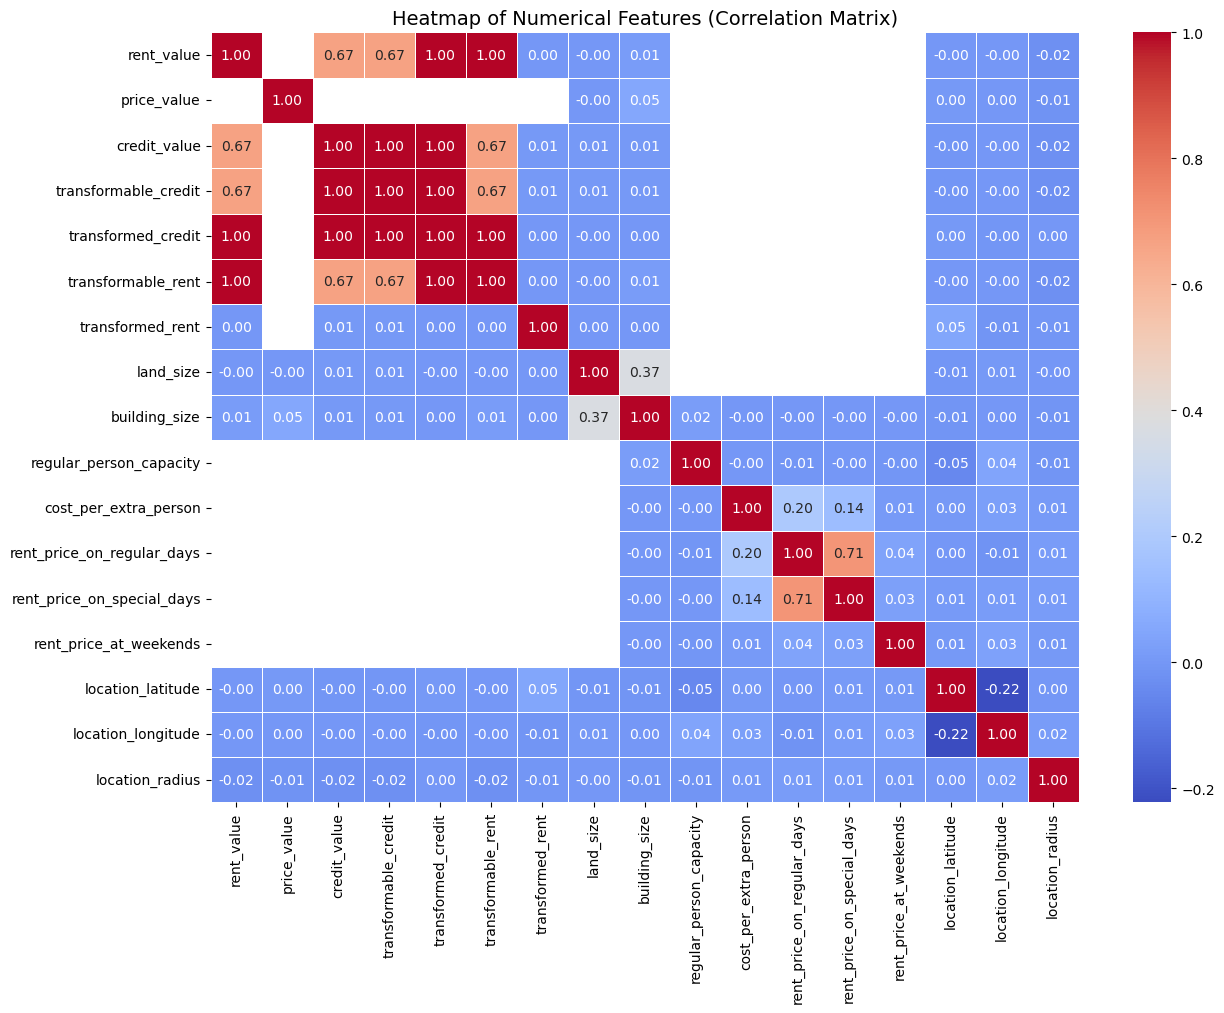

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# فقط ستون‌های عددی
numeric_df = df.select_dtypes(include=["float64", "int64"])

# محاسبه ماتریس همبستگی
corr = numeric_df.corr()

# رسم Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap of Numerical Features (Correlation Matrix)", fontsize=14)
plt.show()


In [41]:
df["land_size"].dropna().count()/1000000

np.float64(0.186396)

In [42]:
df["building_size"].dropna().count()/1000000

np.float64(0.980394)

In [43]:
df[["building_size", "price_value"]].describe()


,building_size,price_value
count,9.803940e+05,5.683460e+05
mean,4.440648e+03,1.736537e+10
std,1.367118e+05,5.878739e+11
min,1.000000e+00,0.000000e+00
25%,7.500000e+01,1.400000e+09
50%,1.030000e+02,2.840000e+09
75%,1.650000e+02,5.900000e+09
max,1.000000e+07,1.000000e+14


In [45]:
def audit_num(s: pd.Series, name=None):
    s = pd.to_numeric(s, errors="coerce")
    name = name or s.name
    n = len(s)
    out = {
        "col": name,
        "count_non_null": int(s.notna().sum()),
        "missing_%": round(s.isna().mean()*100, 2),
        "zeros_%": round((s==0).mean()*100, 2),
        "negatives_%": round((s<0).mean()*100, 2),
        "min": s.min(),
        "q01": s.quantile(0.01),
        "q25": s.quantile(0.25),
        "median": s.quantile(0.50),
        "q75": s.quantile(0.75),
        "q99": s.quantile(0.99),
        "max": s.max(),
        "nunique": s.nunique(dropna=True)
    }
    print(pd.Series(out))
    # نشان دادن بزرگ‌ترین و کوچک‌ترین‌ها برای حس بهتر از پرت‌ها
    print("\nSmallest 5:\n", s.sort_values().head(5).to_string(index=False))
    print("\nLargest 5:\n",  s.sort_values(ascending=False).head(5).to_string(index=False))


In [46]:
audit_num(df["price_value"], "price_value")


col                    price_value
count_non_null              568346
missing_%                    43.17
zeros_%                       0.19
negatives_%                    0.0
min                            0.0
q01                         3400.0
q25                   1400000000.0
median                2840000000.0
q75                   5900000000.0
q99                  85000000000.0
max               99999999999999.0
nunique                      12943
dtype: object

Smallest 5:
 0.0
0.0
0.0
0.0
0.0

Largest 5:
 1.000000e+14
1.000000e+14
1.000000e+14
1.000000e+14
1.000000e+14


In [47]:
# تبدیل به float (به‌صورت ایمن)
df["price_value"] = pd.to_numeric(df["price_value"], errors="coerce")

# حذف مقادیر منفی یا صفر (غیرواقعی برای قیمت فروش)
df.loc[df["price_value"] <= 0, "price_value"] = np.nan

# برش دادن داده‌ها بین 1٪ و 99٪ برای حذف پرت‌ها
q_low, q_high = df["price_value"].quantile([0.01, 0.99])
df["price_value"] = df["price_value"].clip(lower=q_low, upper=q_high)

# چک مجدد خلاصه داده‌ها
audit_num(df["price_value"], "price_value_cleaned")


col               price_value_cleaned
count_non_null                 566444
missing_%                       43.36
zeros_%                           0.0
negatives_%                       0.0
min                          111111.0
q01                          111111.0
q25                      1410000000.0
median                   2850000000.0
q75                      5923500000.0
q99                85132489999.994156
max                85156999999.994873
nunique                         11493
dtype: object

Smallest 5:
 111111.0
111111.0
111111.0
111111.0
111111.0

Largest 5:
 8.515700e+10
8.515700e+10
8.515700e+10
8.515700e+10
8.515700e+10


In [48]:
df["price_value"] = df["price_value"].astype(float)
df["price_value"].dtypes


dtype('float64')

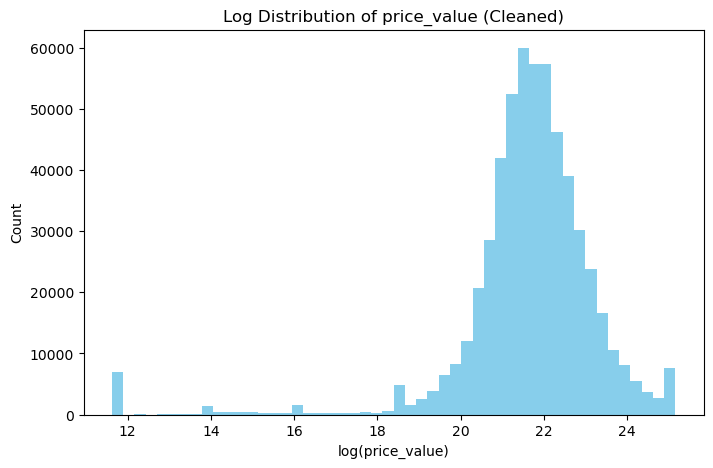

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(np.log1p(df["price_value"].dropna()), bins=50, color='skyblue')
plt.title("Log Distribution of price_value (Cleaned)")
plt.xlabel("log(price_value)")
plt.ylabel("Count")
plt.show()


In [7]:
df["city_slug"].unique()[:10]

array(['karaj', 'tehran', 'mashhad', 'ahvaz', 'kermanshah',
       'mahdasht-city', 'pardis-city', 'foolad-shahr', 'rasht', 'mahabad'],
      dtype=object)

In [8]:
df_tehran = df[df["city_slug"] == "tehran"].copy()

In [9]:
df_tehran.head(5)

,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,26000000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN
3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,95000000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,residential-sell,apartment-sell,tehran,dardasht,2024-09-01 00:00:00,مشاور املاک,♡♡♡♡♡♡بنام خدا♡♡♡♡♡♡\n♡♡♡عرض ادب واحترام♡♡♡\n♡...,اپارتمان ۱۰۰متری طبقه۳و۴ فول دردشت شمالی,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.729832,51.505466,500.0
11,residential-rent,apartment-rent,tehran,gisha,2024-08-01 00:00:00,مشاور املاک,‼️‼️ارزنده ترین واحد منطقه ‼️‼️ \n\n✅ 91 متر ب...,گیشا / ۹۱ متر /فرعی زوج مشرف به پارک گفتگو/ ار...,مجانی,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.733952,51.380608,500.0


In [11]:
df_tehran = df_tehran.reset_index(drop=True)

In [12]:
df_tehran.to_csv("tehran.csv", index=False, encoding="utf-8-sig")

In [11]:
df.describe()

,rent_value,price_value,credit_value,transformable_credit,transformed_credit,transformable_rent,transformed_rent,land_size,building_size,regular_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
count,3.513220e+05,5.683460e+05,3.520950e+05,3.520850e+05,7.240900e+04,3.512480e+05,7.240900e+04,1.863960e+05,9.803940e+05,29870.000000,1.024100e+04,1.806800e+04,1.046300e+04,1.355100e+04,655608.000000,655608.000000,339699.000000
mean,4.102299e+10,1.736537e+10,4.872084e+10,4.872222e+10,8.557025e+09,4.103164e+10,1.619934e+07,4.165480e+03,4.440648e+03,6.557650,1.209785e+10,1.389016e+11,2.355548e+10,3.156551e+10,34.982108,51.629743,465.149147
std,3.807534e+12,5.878739e+11,4.341346e+12,4.341407e+12,2.064576e+12,3.807935e+12,5.217890e+07,1.218927e+05,1.367118e+05,7.698655,1.103482e+12,7.042335e+12,1.542049e+12,2.434942e+12,2.379169,3.160920,125.896250
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,23.626478,40.162369,0.000000
25%,1.111110e+05,1.400000e+09,1.000000e+08,1.000000e+08,2.000000e+08,1.111110e+05,1.000000e+06,1.100000e+02,7.500000e+01,3.000000,5.000000e+04,4.000000e+05,6.000000e+05,5.500000e+05,34.553551,50.677175,500.000000
50%,5.000000e+06,2.840000e+09,2.500000e+08,2.500000e+08,4.000000e+08,5.000000e+06,6.000000e+06,1.950000e+02,1.030000e+02,4.000000,1.000000e+05,8.000000e+05,1.200000e+06,1.100000e+06,35.723312,51.345791,500.000000
75%,1.200000e+07,5.900000e+09,5.000000e+08,5.000000e+08,8.500000e+08,1.200000e+07,1.500000e+07,2.800000e+02,1.650000e+02,7.000000,2.000000e+05,1.600000e+06,2.500000e+06,2.500000e+06,36.307013,51.805291,500.000000
max,1.000000e+15,1.000000e+14,1.000000e+15,1.000000e+15,5.555556e+14,1.000000e+15,3.000000e+09,1.000000e+07,1.000000e+07,50.000000,1.111111e+14,5.006007e+14,1.111111e+14,2.002503e+14,40.358055,74.511620,500.000000
